In [1]:
import re
import warnings
from collections import Counter

import nltk
import numpy as np
import pandas as pd
from nltk import word_tokenize
from nltk.corpus import stopwords

warnings.filterwarnings("ignore")

nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
def tokenize(text):
    """Токенизирует входящий текст"""
    text = text.lower()
    text = re.sub(r'[^а-яa-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


df = pd.read_csv("../data/events/2_struct/2000-2025.csv")  #
df["tokens"] = df["event"].apply(tokenize)
df.head()

,date_start,date_end,event,tokens
0,2000-01-01,NaN,Деноминация белорусского рубля;,"[деноминация, белорусского, рубля]"
1,2000-01-01,NaN,"В связи с «проблемой-2000», в Иране объявлен н...","[связи, проблемой, иране, объявлен, нерабочий,..."
2,2000-01-01,NaN,"Вступление в силу закона в Великобритании, сог...","[вступление, силу, закона, великобритании, сог..."
3,2000-01-02,NaN,Крушение украинского сухогруза типа «река-море...,"[крушение, украинского, сухогруза, типа, рекам..."
4,2000-01-03,NaN,Обстрел из гранатомёта территории российского ...,"[обстрел, гранатомта, территории, российского,..."


In [3]:
from gensim.models import Word2Vec

corpus = df["tokens"].tolist()

total_words = sum(len(tokens) for tokens in corpus)
print(f"Всего слов (токенов): {total_words}")

unique_words = len(set(word for tokens in corpus for word in tokens))
print(f"Уникальных слов: {unique_words}")

corpus[0]

Всего слов (токенов): 61984
Уникальных слов: 17616


['деноминация', 'белорусского', 'рубля']

In [4]:
def vectorize(tokens, model):
    """
    Преобразует список токенов в один вектор события на основе обученной модели Word2Vec.
    """
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)  # вопросы по поводу среднего, почему берем именно среднее?


model = Word2Vec(
    sentences=corpus,
    vector_size=100,  # размерность векторов
    window=5,
    min_count=2,
    sg=1,  # skip-gram,
    epochs=20,
    seed=42
)
df["vector"] = df["tokens"].apply(lambda t: vectorize(t, model))
X = np.vstack(df["vector"].values)
X.shape

(5644, 100)

In [5]:
from sklearn.preprocessing import normalize
import hdbscan

# 1️⃣ Нормализуем векторы (каждый до единичной длины)
X_norm = normalize(X, norm='l2')

# 2️⃣ Обучаем HDBSCAN с метрикой cosine
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    metric='cosine',
    algorithm='generic',
)

# 3️⃣ Кластеризация
labels = clusterer.fit_predict(X_norm)
df["cluster"] = labels

# 4️⃣ Проверяем результат
print("Количество кластеров:", len(set(labels)) - (1 if -1 in labels else 0))

Количество кластеров: 56


In [6]:
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = Counter(tokens).most_common(10)
    print(f"\nКластер {cluster_id}: {[w for w, _ in common]}")


Кластер -1: ['выборы', 'сша', 'президента', 'россии', 'президент', 'года', 'победу', 'выборов', 'парламентские', 'страны']

Кластер 0: ['дипломатические', 'отношения', 'установили', 'разорвала', 'отношение', 'узбекистан', 'установлены', 'бутан', 'украина', 'арменией']

Кластер 1: ['перепись', 'населения', 'прошла', 'украине', 'всероссийская', 'республике', 'эстонии', 'болгарии', 'литве', 'великобритании']

Кластер 2: ['церемония', 'состоялась', 'вручения', 'прошла', 'лосанджелесе', 'оскар', 'лучшим', 'фильмом', 'наград', 'премьера']

Кластер 3: ['игр', 'олимпийских', 'летних', 'года', 'зимних', 'токио', 'проведение', 'церемония', 'столицей', 'прошла']

Кластер 4: ['православной', 'церкви', 'собор', 'русской', 'украине', 'церковь', 'архиерейский', 'патриархата', 'автокефалии', 'православная']

Кластер 5: ['день', 'единый', 'голосования', 'россии', 'прошл', 'официальнй', 'траура', 'погибшим', 'апл', 'курск']

Кластер 6: ['президента', 'путина', 'владимира', 'российской', 'федерации', 'р

In [7]:
print("==================== События по кластерам ====================")
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]

    print(f"🟩 Кластер {cluster_id} ({len(subset)} событий)")
    for event in subset["event"].head(10):  # показываем первые 10 событий
        print(f"  - {event}")

    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = [w for w, _ in Counter(tokens).most_common(10)]
    print(f"  🗝️ Ключевые слова: {common}")

==================== События по кластерам ====================
🟩 Кластер -1 (3374 событий)
  - В связи с «проблемой-2000», в Иране объявлен нерабочий день;
  - Вступление в силу закона в Великобритании, согласно которому вес всех продуктов, имеющихся в продаже, обозначается в метрической системе, а не в традиционных для страны унциях и фунтах.
  - Обстрел из гранатомёта территории российского посольства в Ливане, Бейрут;
  - Победа коалиции социал-демократов-социал-либералов, вместе с блоком из четырёх других партий (во главе с Крестьянской партией) на парламентских выборах в Хорватии, набравших две трети голосов в парламенте, что в дальнейшем позволило изменить конституцию и превратить республику из полу-президентской в парламентскую.
  - Первая рождественская литургия в храме христа спасителя. литургию отслужил патриарх московский и всея руси алексий ii.
  - Переизбрание Ислама Каримова президентом Республики Узбекистан (91,9 % голосов избирателей);
  - Вторая чеченская война: прорыв

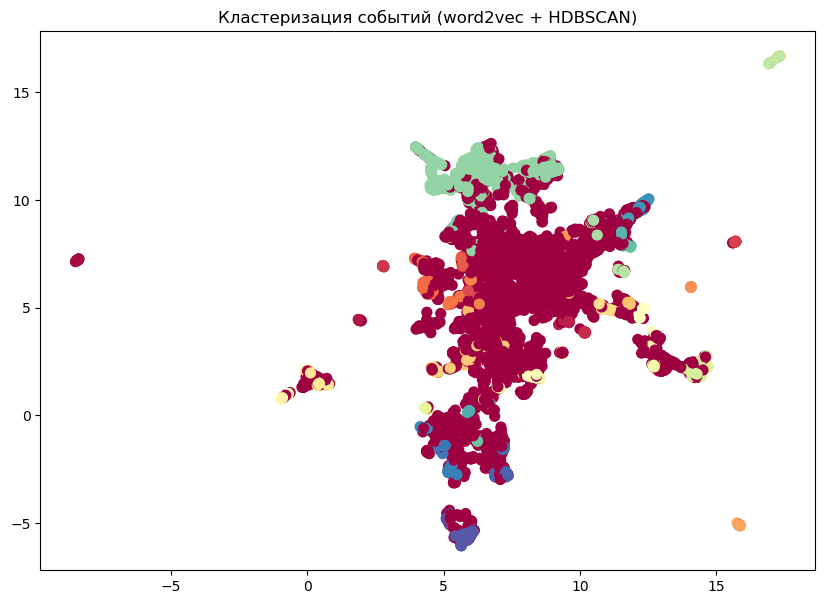

In [8]:
import umap
import matplotlib.pyplot as plt

umap_embeddings = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X_norm)

plt.figure(figsize=(10, 7))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            c=df["cluster"], cmap="Spectral", s=50)
plt.title("Кластеризация событий (word2vec + HDBSCAN)")
plt.show()

In [9]:
from sklearn.metrics import silhouette_score

mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
score

0.33485578398052424

In [10]:
import itertools
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
from tqdm import tqdm

# ==== 3. Пространство гиперпараметров ====
param_grid = {
    "vector_size": [100, 200, 300],
    "window": [3, 5, 8, 10],
    "min_count": [1, 2, 5],
    "sg": [0, 1],  # 0 — CBOW, 1 — Skip-gram
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

results = []

# ==== 4. Перебор параметров ====
for params in tqdm(param_combinations, desc="Grid Search Word2Vec"):
    param_dict = dict(zip(param_names, params))

    # 4.1 Обучаем Word2Vec
    model = Word2Vec(
        sentences=corpus,
        **param_dict,
        workers=4,
        epochs=20,
        seed=42
    )

    # 4.2 Векторизация событий
    X = np.vstack([vectorize(tokens, model) for tokens in corpus])
    X_norm = normalize(X, norm='l2')
    # 4.3 Кластеризация (можно выбрать KMeans или HDBSCAN)
    # HDBSCAN (автоматически подбирает число кластеров)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=10,
        min_samples=3,
        metric='cosine',
        algorithm='generic',
    )
    labels = clusterer.fit_predict(X_norm)

    # Игнорируем шумовые точки (-1)
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        continue

    # ==== 4.4 Метрики ====
    sil = silhouette_score(X_norm[mask], labels[mask])
    db = davies_bouldin_score(X_norm[mask], labels[mask])
    ch = calinski_harabasz_score(X_norm[mask], labels[mask])

    results.append({
        **param_dict,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "clusters": len(set(labels[mask]))
    })

# ==== 5. Анализ результатов ====
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("silhouette", ascending=False)

print("\nЛучшие параметры по silhouette:")
print(results_df.head(10))

# Можно также вывести среднюю оценку с весами
results_df["score_combined"] = (
        results_df["silhouette"] * 2
        - results_df["davies_bouldin"] * 0.5
        + np.log1p(results_df["calinski_harabasz"]) * 0.1
)

print("\nТоп по комбинированному скору:")
results_df.sort_values("score_combined", ascending=False).head(10)

Grid Search Word2Vec: 100%|██████████| 72/72 [04:02<00:00,  3.36s/it]


Лучшие параметры по silhouette:
    vector_size  window  min_count  sg  silhouette  davies_bouldin  \
18          100      10          1   0    0.494880        0.769528   
42          200      10          1   0    0.481966        0.791484   
66          300      10          1   0    0.468564        0.778597   
14          100       8          2   0    0.449057        0.773295   
1           100       3          1   1    0.443820        0.902111   
38          200       8          2   0    0.442749        0.801638   
62          300       8          2   0    0.437516        0.790246   
68          300      10          2   0    0.432579        0.828866   
20          100      10          2   0    0.428502        0.834953   
25          200       3          1   1    0.427327        0.977940   

    calinski_harabasz  clusters  
18        1840.983661        57  
42        2514.532554        60  
66        2344.803725        59  
14        1257.357985        66  
1          435.822254     

,vector_size,window,min_count,sg,silhouette,davies_bouldin,calinski_harabasz,clusters,score_combined
18,100,10,1,0,0.494880,0.769528,1840.983661,57,1.356855
42,200,10,1,0,0.481966,0.791484,2514.532554,60,1.351214
66,300,10,1,0,0.468564,0.778597,2344.803725,59,1.323867
14,100,8,2,0,0.449057,0.773295,1257.357985,66,1.225223
62,300,8,2,0,0.437516,0.790246,1505.232598,56,1.211645
38,200,8,2,0,0.442749,0.801638,1386.775252,58,1.208225
36,200,8,1,0,0.404868,0.801399,2109.201762,59,1.174490
60,300,8,1,0,0.409557,0.780745,1703.463029,58,1.172842
68,300,10,2,0,0.432579,0.828866,1326.202854,57,1.169807
2,100,3,2,0,0.426200,0.831187,1374.559993,68,1.159468


In [11]:
# === 1. Обучаем Word2Vec с выбранными параметрами ===
best_params = {
    "vector_size": 200,
    "window": 8,
    "min_count": 1,
    "sg": 0,  # Skip-gram
    "workers": 4,
    "epochs": 20,
    "seed": 42
}

model = Word2Vec(sentences=corpus, **best_params)

X = np.vstack([vectorize(tokens, model) for tokens in corpus])
X_norm = normalize(X, norm='l2')

# === 3. Кластеризация (можно поменять min_cluster_size) ===
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    metric='cosine',
    algorithm='generic',

)
labels = clusterer.fit_predict(X_norm)
df["tokens"] = corpus
df["cluster"] = labels

# === 4. Метрики качества ===
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X_norm[mask], labels[mask])
    db = davies_bouldin_score(X_norm[mask], labels[mask])
    ch = calinski_harabasz_score(X_norm[mask], labels[mask])
    print(f"Silhouette: {sil:.3f}, Davies–Bouldin: {db:.3f}, Calinski–Harabasz: {ch:.1f}")
else:
    print("Недостаточно кластеров для расчёта метрик")

# === 5. Сводка по кластерам ===
print("\n📊 Кластеры:")
print(df["cluster"].value_counts().sort_index())

# === 6. Вывод топ-слов по каждому кластеру ===
for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens if t in model.wv]
    top_words = [w for w, _ in Counter(tokens).most_common(30)]
    print(f"\nКластер {cluster_id}: {top_words}")

Silhouette: 0.469, Davies–Bouldin: 0.743, Calinski–Harabasz: 2354.8

📊 Кластеры:
cluster
-1     3520
 0       17
 1       13
 2       12
 3       14
       ... 
 57     169
 58      11
 59      12
 60     432
 61      41
Name: count, Length: 63, dtype: int64

Кластер 0: ['война', 'вторая', 'чеченская', 'боевиков', 'нападение', 'го', 'полка', 'грозный', 'внутренних', 'мвд', 'село', 'комсомольское', 'освобождено', 'федеральными', 'войсками', 'послке', 'новогрозненский', 'сотрудниками', 'фсб', 'захвачен', 'доставлен', 'москву', 'террорист', 'салман', 'радуев', 'впоследствии', 'осужднный', 'пожизненному', 'лишению', 'свободы']

Кластер 1: ['единый', 'день', 'голосования', 'россии', 'десятый', 'беларуси']

Кластер 2: ['россии', 'форум', 'казахстана', 'россия', 'межрегионального', 'сотрудничества', 'казахстан', 'приграничных', 'регионов', 'i', 'омск', 'ii', 'челябинск', 'iii', 'уральск', 'iv', 'новосибирск', 'vii', 'устькаменогорск', 'viii', 'астрахань', 'официальное', 'вступление', 'вто', '